# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

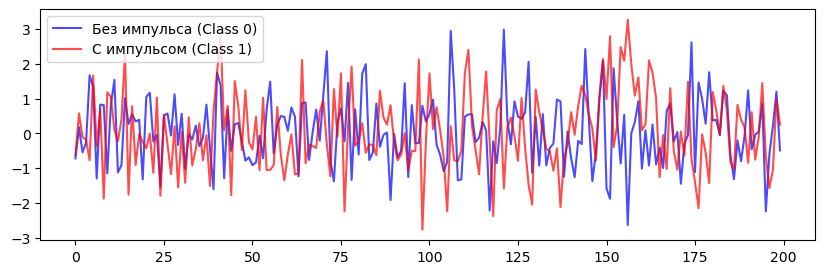

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [5]:
def generate_candidates(ts_list: np.ndarray, min_len: int = 3, max_len: int = 20) -> List[np.ndarray]:
    candidates_set = set()   # store tuples to ensure uniqueness

    n_series, series_len = ts_list.shape

    for length in range(min_len, max_len + 1):
        # sliding window over each series
        for i in range(n_series):
            series = ts_list[i]
            for start in range(series_len - length + 1):
                subseq = tuple(series[start:start + length])
                candidates_set.add(subseq)

    candidates = [np.array(subseq) for subseq in candidates_set]
    return candidates


Total candidates: 2255
Type of container: <class 'list'>
First candidate type: <class 'numpy.ndarray'>
First candidate shape: (13,)
First candidate values:
[-0.54438272  0.11092259 -1.15099358  0.37569802 -0.60063869 -0.29169375
 -0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491 -1.22084365
  0.2088636 ]



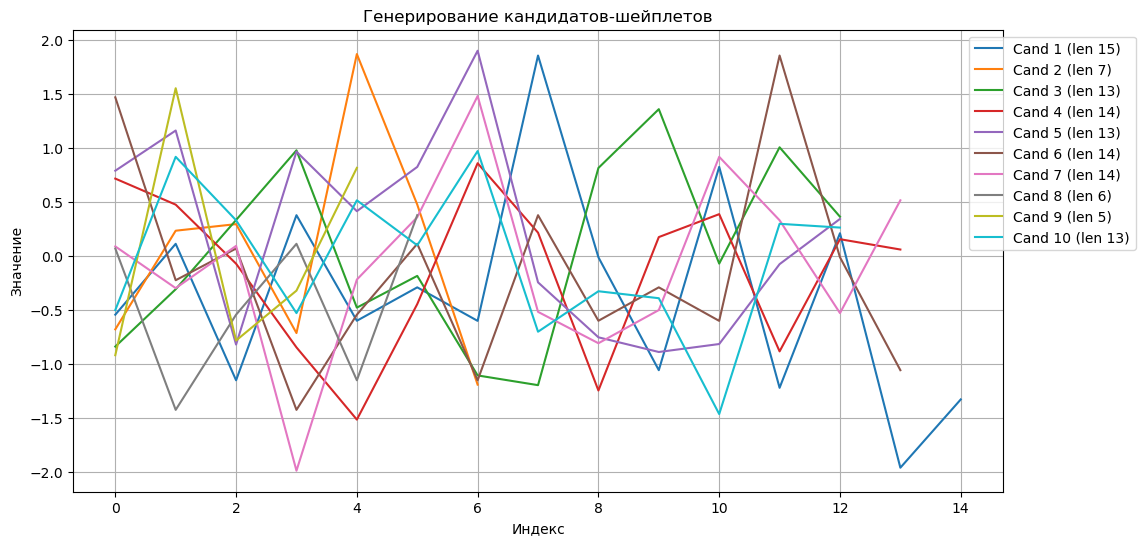

In [8]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(42)
mock_ts_list = np.random.randn(5, 50)

candidates = generate_candidates(mock_ts_list, min_len=5, max_len=15)

print(f"Total candidates: {len(candidates)}")
print(f"Type of container: {type(candidates)}")
print(f"First candidate type: {type(candidates[0])}")
print(f"First candidate shape: {candidates[0].shape}")
print(f"First candidate values:\n{candidates[0]}\n")

plt.figure(figsize=(12, 6))
sample_candidates = random.sample(candidates, min(10, len(candidates)))

for i, cand in enumerate(sample_candidates):
    plt.plot(cand, label=f"Cand {i+1} (len {len(cand)})")

plt.title("Генерирование кандидатов-шейплетов")
plt.xlabel("Индекс")
plt.ylabel("Значение")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.show()

## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [9]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    mean = np.mean(ts)
    std = np.std(ts)
    if std == 0:
        return np.zeros_like(ts)
    return (ts - mean) / std

def calculate_shapelet_distance(shapelet: np.ndarray, time_series: np.ndarray) -> float:
    shapelet_norm = z_normalize(shapelet)
    L = len(shapelet)
    N = len(time_series)
    min_dist = float('inf')

    for start in range(N - L + 1):
        window = time_series[start:start + L]
        window_norm = z_normalize(window)
        dist = np.sqrt(np.sum((shapelet_norm - window_norm) ** 2))
        if dist < min_dist:
            min_dist = dist

    return min_dist


In [10]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

In [11]:
def shapelet_transform(X: np.ndarray, y: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    # TODO:
    # 1. Извлечь кандидатов `generate_candidates` 
    candidates = generate_candidates(X)
    np.random.shuffle(candidates)
    candidates = candidates[:1000]
    shapelet_info = []
    
    # 2. Для каждого кандидата посчитать расстояния `calculate_shapelet_distance` ко всем временным рядам
    # 3. Высчитать `IG` для каждого `calculate_information_gain` (имеет смысл использовать `.sample()` для скорости)
    for shapelet in candidates:
        distances = np.array([calculate_shapelet_distance(shapelet, ts) for ts in X])
        ig, split = calculate_information_gain(distances, y)
        
        shapelet_info.append({
            'shapelet': shapelet,
            'ig': ig,
            'split': split
        })
    # 4. Отсортировать шейплеты по убыванию IG, взять топ K.
    shapelet_info = sorted(shapelet_info, key=lambda x: x['ig'], reverse=True)
    top_shapelets = shapelet_info[:top_k]
    # 5. Сформировать новую матрицу признаков из Distances лучших шейплетов
    
    features = np.zeros((len(X), top_k))
    
    for i, sh_info in enumerate(top_shapelets):
        shapelet = sh_info['shapelet']
        for j, ts in enumerate(X):
            features[j, i] = calculate_shapelet_distance(shapelet, ts)
    
    return features, top_shapelets

Форма новых признаков: (50, 5)
Accuracy: 0.7333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       1.00      0.43      0.60         7

    accuracy                           0.73        15
   macro avg       0.83      0.71      0.70        15
weighted avg       0.82      0.73      0.71        15



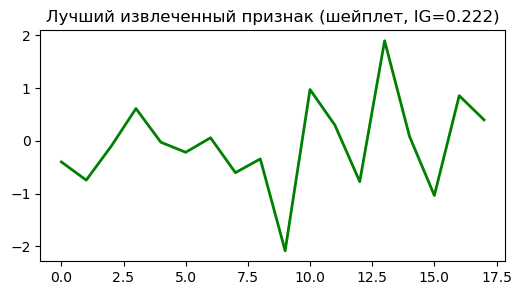

In [12]:
# Итоговое тестирование и Классификация
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features, top_shapelets = shapelet_transform(X, y, top_k=5)
print(f"Форма новых признаков: {features.shape}")

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6, 3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший извлеченный признак (шейплет, IG={top_shapelets[0]['ig']:.3f})")
plt.show()